# REG Environment & Related

## Research context

Environment & Related (CategoryKey = 5) is a **priority field** under JRG. It received the
**largest student fee reduction of any discipline** studied here, moving from a high-cost cluster
to a substantially lower one in 2021:

| Period | Student contribution (avg) | Commonwealth contribution (avg) |
|--------|---------------------------|----------------------------------|
| 2019   | ~$9,359                    | ~$23,000–$27,000                 |
| 2021+  | ~$5,213 (approx. −44 %)   | Broadly stable                   |

The demand-side incentive from the fee reduction is the strongest of any JRG priority field.
However, Environment & Related is a relatively small field in Australia (~18,000–22,000 students),
and a COVID-driven enrolment spike in 2020 complicates the pre/post comparison.

AUS Environment enrolments peaked in 2020 (21,916) then declined through 2022–23 before
stabilising near 19,300–19,400. UK Environment enrolments were broadly stable across the same
period. The DiD tests whether AUS deviated *differentially* from the UK trend after 2021.

### Identifying strategy (country-level DiD)

$$\log(\text{Enrolments}_{ct}) = \alpha_c + \gamma_t + \beta(\text{AUS}_c \times \text{Post}_t) + \varepsilon_{ct}$$

where $c \in \{\text{AUS, UK}\}$, $\text{Post}_t = \mathbf{1}[t \geq 2021]$, and $\beta$ is the JRG effect for Environment & Related.

**Data window:** AUS 2019–2024 (6 years); UK 2019–2024 (6 years).  \
Overlapping DiD window: 2019–2024 (2 pre-treatment years, 4 post-treatment years).

> **Important data limitation — UK panel starts at 2019:**  \
> The UK comparison file maps the JACS subject '06 Physical Sciences' to CategoryKey 5 for
> academic years 2016/17–2018/19. This is an incorrect taxonomy mapping: Physical Sciences
> belong to a different discipline cluster (key = 1) and do not correspond to Environment &
> Related subjects (Agriculture, Geography & Environmental Studies). Therefore, UK data for
> key = 5 prior to 2019 is excluded from the DiD panel. Only 2019–2024 UK data — sourced from
> the correctly-mapped CAH subjects — is used. This restriction reduces the panel to N = 12
> (df = 4), limiting statistical power.


In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

START = Path.cwd()
ROOT = START
while ROOT != ROOT.parent and not (ROOT / 'data').exists():
    ROOT = ROOT.parent

AUS_PATH  = ROOT / 'data' / 'clean' / 'EnrollmentsAUS_category_with_numeric_key.csv'
UK_PATH   = ROOT / 'data' / 'clean' / 'uk_grouped' / 'with_categorykey' / 'UK_enrollments_grouped_comparison_all_years_with_categorykey.csv'
FUND_PATH = ROOT / 'data' / 'clean' / 'AnnualFundingAUS2019-2026_with_category_key.csv'

assert AUS_PATH.exists(),  f'Missing: {AUS_PATH}'
assert UK_PATH.exists(),   f'Missing: {UK_PATH}'
assert FUND_PATH.exists(), f'Missing: {FUND_PATH}'
print('Project root:', ROOT)
print('All data files found.')


Project root: C:\Users\neddp\ECC3479-Project-JRGS
All data files found.


## 1. AUS Descriptive Analysis

Examine Australia-only Environment & Related data (2016–2024) to characterise the enrolment
trend and test a simple pre/post break. AUS-only OLS uses a log-linear specification with HC3
robust SEs. Note the COVID-driven spike in 2020 — a key feature of this discipline's trend.


AUS Environment & Related -- enrolment data:


,year,enrollments,log_enrollments
0,2016,18537,9.827524
1,2017,18260,9.812468
2,2018,18055,9.801178
3,2019,18747,9.838789
4,2020,21916,9.994972
5,2021,20776,9.941554
6,2022,19476,9.876938
7,2023,19284,9.867031
8,2024,19376,9.871790


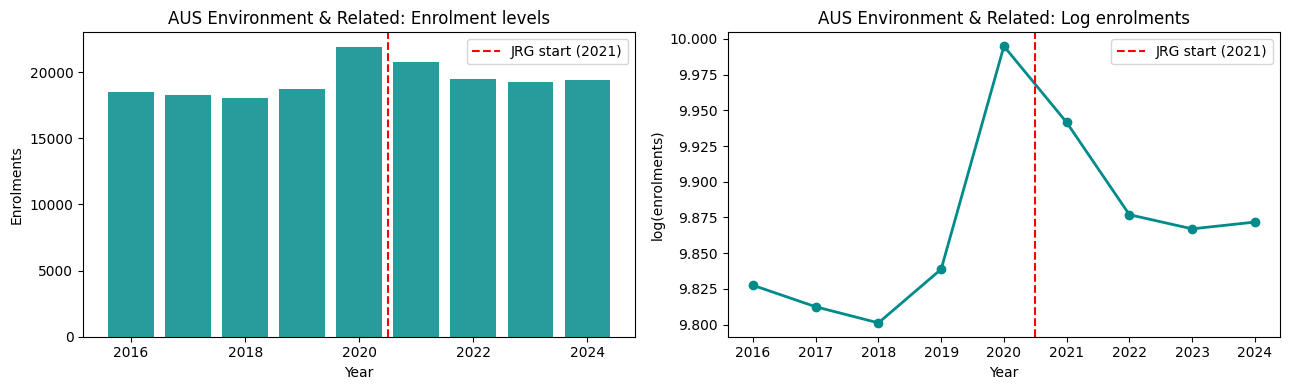

In [2]:
aus_raw   = pd.read_csv(AUS_PATH)
year_cols = [c for c in aus_raw.columns if str(c).isdigit()]

aus_long = aus_raw.melt(
    id_vars=['Category', 'CategoryKey'],
    value_vars=year_cols,
    var_name='year',
    value_name='enrollments',
)
aus_long['year']        = aus_long['year'].astype(int)
aus_long['enrollments'] = pd.to_numeric(aus_long['enrollments'], errors='coerce')

arch_aus = aus_long[aus_long['CategoryKey'] == 5].copy().sort_values('year').reset_index(drop=True)
arch_aus['log_enrollments'] = np.log(arch_aus['enrollments'])
arch_aus['year_c']   = arch_aus['year'] - 2019
arch_aus['year_c2']  = arch_aus['year_c'] ** 2
arch_aus['post_jrg'] = (arch_aus['year'] >= 2021).astype(int)

print('AUS Environment & Related -- enrolment data:')
display(arch_aus[['year', 'enrollments', 'log_enrollments']].reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(arch_aus['year'], arch_aus['enrollments'], color='darkcyan', alpha=0.85)
axes[0].axvline(2020.5, linestyle='--', color='red', linewidth=1.5, label='JRG start (2021)')
axes[0].set_title('AUS Environment & Related: Enrolment levels')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Enrolments'); axes[0].legend()

axes[1].plot(arch_aus['year'], arch_aus['log_enrollments'], 'o-', color='darkcyan', linewidth=2)
axes[1].axvline(2020.5, linestyle='--', color='red', linewidth=1.5, label='JRG start (2021)')
axes[1].set_title('AUS Environment & Related: Log enrolments')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('log(enrolments)'); axes[1].legend()

plt.tight_layout()
plt.show()


In [3]:
def summary_table(result, vars_):
    ci = result.conf_int()
    rows = []
    for v in vars_:
        if v not in result.params.index:
            continue
        rows.append({
            'Variable': v,
            'beta':     round(result.params[v], 4),
            'SE (HC3)': round(result.bse[v], 4),
            'p':        round(result.pvalues[v], 4),
            'CI lo':    round(ci.loc[v, 0], 4),
            'CI hi':    round(ci.loc[v, 1], 4),
        })
    out = pd.DataFrame(rows).set_index('Variable')
    display(out)
    print(f'R^2 = {result.rsquared:.4f} | Adj. R^2 = {result.rsquared_adj:.4f} | N = {int(result.nobs)}')

m_linear = smf.ols('log_enrollments ~ post_jrg + year_c',           data=arch_aus).fit(cov_type='HC3')
m_quad   = smf.ols('log_enrollments ~ post_jrg + year_c + year_c2', data=arch_aus).fit(cov_type='HC3')

print('=== AUS-only OLS: linear time trend ===')
summary_table(m_linear, ['Intercept', 'post_jrg', 'year_c'])
b_aus = m_linear.params['post_jrg']
print(f'\npost_jrg: ~{b_aus*100:.2f}% change in AUS enrolments post-JRG (controlling for linear trend)')

print('\n=== AUS-only OLS: quadratic time trend ===')
summary_table(m_quad, ['Intercept', 'post_jrg', 'year_c', 'year_c2'])


=== AUS-only OLS: linear time trend ===


,beta,SE (HC3),p,CI lo,CI hi
Variable,,,,,
Intercept,9.8718,0.0707,0.0000,9.7333,10.0102
post_jrg,-0.0411,0.1860,0.8249,-0.4056,0.3234
year_c,0.0168,0.0307,0.5851,-0.0434,0.0770


R^2 = 0.2164 | Adj. R^2 = -0.0449 | N = 9

post_jrg: ~-4.11% change in AUS enrolments post-JRG (controlling for linear trend)

=== AUS-only OLS: quadratic time trend ===


,beta,SE (HC3),p,CI lo,CI hi
Variable,,,,,
Intercept,9.8895,0.0785,0.0000,9.7357,10.0434
post_jrg,-0.0145,0.1710,0.9326,-0.3497,0.3207
year_c,0.0212,0.0363,0.5586,-0.0499,0.0923
year_c2,-0.0044,0.0056,0.4293,-0.0155,0.0066


R^2 = 0.3964 | Adj. R^2 = 0.0342 | N = 9


## 2. DiD Panel Construction

Combine AUS and UK Environment & Related data into a country x year panel (2019–2024).

**UK year mapping:** start-year rule — 2019/20 → 2019, 2020/21 → 2020, etc.

**Why 2019+ only?** UK data in the comparison file maps JACS subject '06 Physical Sciences'
to CategoryKey 5 for 2016/17–2018/19. Physical Sciences is not an Environment & Related
subject. The correct UK subjects (Agriculture & related; Geography & Environmental Studies)
are only reliably mapped from 2019/20 onwards under the CAH taxonomy. Pre-2019 UK rows
for key = 5 are therefore excluded.

**Treatment indicators:**
- `treated = 1` for AUS, `0` for UK
- `post = 1` for 2021+
- `did = treated x post` (main DiD interaction)
- `treated_covid2020`, `treated_covid2021`: AUS-specific COVID shock controls (reference only;
  adding these at N = 12 reduces df from 4 to 2, making inference highly unreliable)


In [4]:
uk_raw  = pd.read_csv(UK_PATH)
arch_uk = uk_raw[uk_raw['categorykey'] == 5].copy()

arch_uk['year'] = arch_uk['AcademicYear'].str[:4].astype(int)
arch_uk = arch_uk[arch_uk['year'] >= 2019]  # exclude incorrectly-mapped pre-2019 rows
arch_uk['enrollments'] = pd.to_numeric(arch_uk['Total UK'], errors='coerce')

# Key=5 has three subject rows per year (Agriculture, Geography natural, Geography social)
# Sum them to get the total UK Environment & Related enrolment per year
arch_uk = arch_uk.groupby('year', as_index=False)['enrollments'].sum()
arch_uk['country'] = 'UK'

arch_aus_did = arch_aus[arch_aus['year'] >= 2019][['year', 'enrollments']].copy()
arch_aus_did['country'] = 'AUS'

panel = pd.concat([arch_aus_did, arch_uk], ignore_index=True).sort_values(['country', 'year']).reset_index(drop=True)
panel['log_enrollments']   = np.log(panel['enrollments'])
panel['treated']           = (panel['country'] == 'AUS').astype(int)
panel['post']              = (panel['year'] >= 2021).astype(int)
panel['did']               = panel['treated'] * panel['post']
panel['covid_2020']        = (panel['year'] == 2020).astype(int)
panel['covid_2021']        = (panel['year'] == 2021).astype(int)
panel['treated_covid2020'] = panel['treated'] * panel['covid_2020']
panel['treated_covid2021'] = panel['treated'] * panel['covid_2021']
panel['year_c']            = panel['year'] - 2020

print('DiD panel -- Environment & Related (AUS vs UK, 2019-2024):')
display(panel[['country','year','enrollments','log_enrollments','treated','post','did']].reset_index(drop=True))
print(f'\nShape: {panel.shape} | Pre-treatment: {sorted(panel[panel["post"]==0]["year"].unique())} | Post: {sorted(panel[panel["post"]==1]["year"].unique())}')
print(f'N = {len(panel)} | Countries = 2 | Years = {panel["year"].nunique()}')


DiD panel -- Environment & Related (AUS vs UK, 2019-2024):


,country,year,enrollments,log_enrollments,treated,post,did
0,AUS,2019,18747.0,9.838789,1,0,0
1,AUS,2020,21916.0,9.994972,1,0,0
2,AUS,2021,20776.0,9.941554,1,1,1
3,AUS,2022,19476.0,9.876938,1,1,1
4,AUS,2023,19284.0,9.867031,1,1,1
5,AUS,2024,19376.0,9.871790,1,1,1
6,UK,2019,60470.0,11.009903,0,0,0
7,UK,2020,63265.0,11.055088,0,0,0
8,UK,2021,65105.0,11.083757,0,1,0
9,UK,2022,65405.0,11.088354,0,1,0



Shape: (12, 12) | Pre-treatment: [np.int64(2019), np.int64(2020)] | Post: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
N = 12 | Countries = 2 | Years = 6


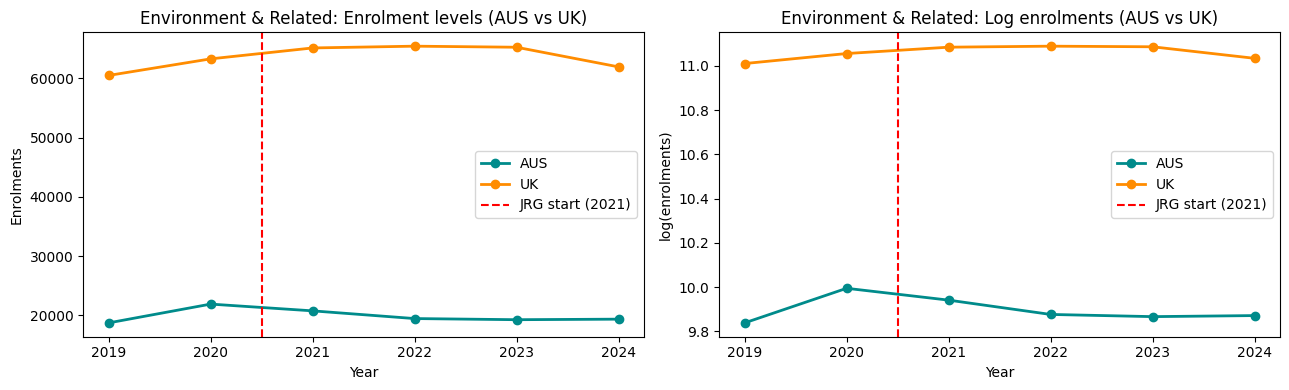

Pre/post log-enrolment averages:
  AUS: pre = 9.9169, post = 9.8893, change = -0.0276
  UK: pre = 11.0325, post = 11.0728, change = +0.0403


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colours = {'AUS': 'darkcyan', 'UK': 'darkorange'}

for country, grp in panel.groupby('country'):
    grp = grp.sort_values('year')
    axes[0].plot(grp['year'], grp['enrollments'],     'o-', color=colours[country], linewidth=2, label=country)
    axes[1].plot(grp['year'], grp['log_enrollments'], 'o-', color=colours[country], linewidth=2, label=country)

for ax in axes:
    ax.axvline(2020.5, linestyle='--', color='red', linewidth=1.5, label='JRG start (2021)')
    ax.legend(); ax.set_xlabel('Year')

axes[0].set_title('Environment & Related: Enrolment levels (AUS vs UK)')
axes[0].set_ylabel('Enrolments')
axes[1].set_title('Environment & Related: Log enrolments (AUS vs UK)')
axes[1].set_ylabel('log(enrolments)')

plt.tight_layout()
plt.show()

print('Pre/post log-enrolment averages:')
for country, grp in panel.groupby('country'):
    pre  = grp[grp['post'] == 0]['log_enrollments'].mean()
    post = grp[grp['post'] == 1]['log_enrollments'].mean()
    print(f'  {country}: pre = {pre:.4f}, post = {post:.4f}, change = {post - pre:+.4f}')


## 3. Main DiD Specification (TWFE)

**Estimating equation:**

$$\log(\text{Enrolments}_{ct}) = \alpha_c + \gamma_t + \beta(\text{AUS}_c \times \text{Post}_t) + \varepsilon_{ct}$$

Implemented as OLS with `treated` (country FE) + `C(year)` (year FEs) + `did`. All SEs are HC3 robust.

> **Degrees-of-freedom constraint:** N = 12 (2 countries x 6 years). Country FE + year FEs + intercept + did
> = 8 parameters, leaving **df = 4**. This is the tightest panel among the disciplines studied; inference
> should be interpreted with caution. Adding AUS-specific COVID terms reduces df to 2, making
> inference unreliable. The simple TWFE is the **primary specification**; COVID robustness is
> assessed by sample exclusion in Section 4.

> **Context:** The 2020 spike in AUS enrolments (COVID-related demand shift) is visible in the
> panel. Since 2020 is the final pre-treatment year and is elevated, the TWFE year FE for 2020
> captures this common time effect. AUS-specific COVID sensitivity is assessed in Section 4.


In [6]:
formula_main = 'log_enrollments ~ treated + did + C(year)'
model_main = smf.ols(formula_main, data=panel).fit(cov_type='HC3')
print('=== Main DiD -- TWFE OLS (HC3) ===')
print(model_main.summary())

did_b  = model_main.params['did']
did_se = model_main.bse['did']
did_p  = model_main.pvalues['did']
did_ci = model_main.conf_int().loc['did']
pct    = (np.exp(did_b) - 1) * 100

print('\n--- Key result ---')
print(f'DiD estimate (beta_did): {did_b:.4f}')
print(f'SE (HC3):                {did_se:.4f}')
print(f'p-value:                 {did_p:.4f}')
print(f'95% CI:                  [{did_ci[0]:.4f}, {did_ci[1]:.4f}]')
print(f'Approx. % effect:        {pct:+.2f}%')
print(f'df_resid:                {int(model_main.df_resid)}')
direction = 'higher' if did_b > 0 else 'lower'
print(f'\nInterpretation: Post-JRG (2021+), AUS Environment enrolments were')
print(f'approximately {abs(pct):.1f}% {direction} than the UK trend would predict.')

# COVID-controlled spec for reference (df=2, inference unreliable)
formula_covid = 'log_enrollments ~ treated + did + treated_covid2020 + treated_covid2021 + C(year)'
m_covid = smf.ols(formula_covid, data=panel).fit(cov_type='HC3')
b_cv = m_covid.params.get('did', np.nan)
p_cv = m_covid.pvalues.get('did', np.nan)
print(f'\nCOVID-controlled spec (df=2, reference only): beta_did = {b_cv:.4f}, p = {p_cv:.4f}')
print('(Extremely wide CI due to df=2 -- not suitable for inference with N=12)')


=== Main DiD -- TWFE OLS (HC3) ===
                            OLS Regression Results                            
Dep. Variable:        log_enrollments   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     229.8
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           4.82e-05
Time:                        19:33:17   Log-Likelihood:                 29.466
No. Observations:                  12   AIC:                            -42.93
Df Residuals:                       4   BIC:                            -39.05
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Interce

In [7]:
df_pl = panel.set_index(['country', 'year'])

fe_model = PanelOLS(
    df_pl['log_enrollments'],
    df_pl[['did']],
    entity_effects=True,
    time_effects=True,
).fit(cov_type='robust')

print('=== PanelOLS TWFE (cross-check) ===')
print(fe_model.summary)

print(f'\nOLS DiD estimate:      {did_b:.6f}')
print(f'PanelOLS DiD estimate: {fe_model.params["did"]:.6f}')
match = abs(did_b - fe_model.params['did']) < 1e-5
print('Estimates match' if match else 'WARNING: mismatch')


=== PanelOLS TWFE (cross-check) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:        log_enrollments   R-squared:                        0.3724
Estimator:                   PanelOLS   R-squared (Between):             -0.0041
No. Observations:                  12   R-squared (Within):              -0.0521
Date:                Sat, Apr 25 2026   R-squared (Overall):             -0.0041
Time:                        19:33:17   Log-likelihood                    29.466
Cov. Estimator:                Robust                                           
                                        F-statistic:                      2.3735
Entities:                           2   P-value                           0.1983
Avg Obs:                       6.0000   Distribution:                     F(1,4)
Min Obs:                       6.0000                                           
Max Obs:                       6.0000   F-statistic (robust):            

## 4. COVID Sensitivity

Three variants using the simple TWFE formula across different sample restrictions.
With N = 12 (df = 4) in the base case, dropping years reduces df rapidly.
The relevant check is consistency of **sign and magnitude** across variants.

| Spec | N | df | Expected inference quality |
|------|---|----|----------------------------|
| Full panel (2019-2024) | 12 | 4 | Limited but usable |
| Drop 2020 | 10 | 3 | Marginal |
| Drop 2020 + 2021 | 8 | 2 | Very limited |


In [8]:
formula_simple = 'log_enrollments ~ treated + did + C(year)'

variants = {
    'Full panel (2019-2024)': panel,
    'Drop 2020':              panel[panel['year'] != 2020].copy(),
    'Drop 2020 + 2021':       panel[~panel['year'].isin([2020, 2021])].copy(),
}

rows = []
for label, data in variants.items():
    m = smf.ols(formula_simple, data=data).fit(cov_type='HC3')
    b  = m.params.get('did', np.nan)
    se = m.bse.get('did', np.nan)
    p  = m.pvalues.get('did', np.nan)
    ci = m.conf_int().loc['did'] if 'did' in m.conf_int().index else [np.nan, np.nan]
    rows.append({
        'Specification': label,
        'N':             int(m.nobs),
        'df_resid':      int(m.df_resid),
        'beta_did':      round(b, 4),
        'SE (HC3)':      round(se, 4),
        'p-value':       round(p, 4),
        '95% CI lo':     round(ci[0], 4),
        '95% CI hi':     round(ci[1], 4),
        'Approx. %':     round((np.exp(b) - 1) * 100, 2) if pd.notna(b) else np.nan,
    })

print('=== COVID Sensitivity (simple TWFE, all variants) ===')
display(pd.DataFrame(rows).set_index('Specification'))
print('\nKey takeaway: check whether beta_did sign and magnitude are stable across sample restrictions.')
print('With only df = 4 in the full panel, CIs are wide and p-values should not be over-interpreted.')


=== COVID Sensitivity (simple TWFE, all variants) ===


,N,df_resid,beta_did,SE (HC3),p-value,95% CI lo,95% CI hi,Approx. %
Specification,,,,,,,,
Full panel (2019-2024),12,4,-0.0679,0.1151,0.5555,-0.2935,0.1578,-6.56
Drop 2020,10,3,-0.0124,7.2112,0.9986,-14.1460,14.1213,-1.23
Drop 2020 + 2021,8,2,-0.0261,13.3334,0.9984,-26.1590,26.1068,-2.58



Key takeaway: check whether beta_did sign and magnitude are stable across sample restrictions.
With only df = 4 in the full panel, CIs are wide and p-values should not be over-interpreted.


## 5. Parallel Trends Check (Event Study)

Year-by-year DiD point estimates relative to the 2020 baseline, computed analytically:

$$\hat{\delta}_t = (\log Y_{\text{AUS},t} - \log Y_{\text{AUS},2020}) - (\log Y_{\text{UK},t} - \log Y_{\text{UK},2020})$$

This is numerically identical to a regression-based DiD coefficient but avoids the degrees-of-freedom
problem (2 obs per year, 2 params, df = 0) that arises with 2 countries.

> **Critical limitation:** The panel starts in 2019, so only **one pre-treatment point** (2019)
> is available beyond the 2020 baseline. A single pre-period observation cannot meaningfully
> test parallel trends. This is the most significant identification weakness of the Environment
> & Related analysis and a direct consequence of the UK taxonomy mapping problem.


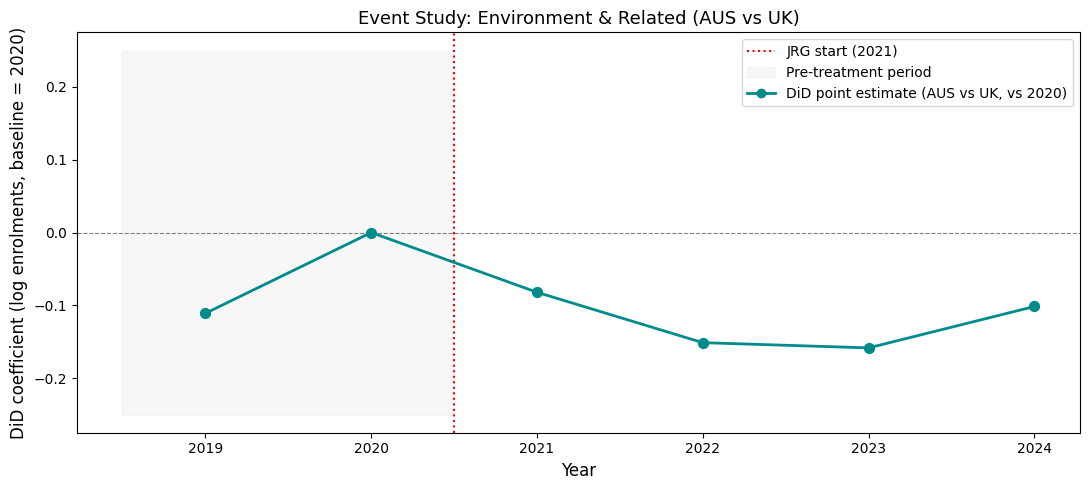

Event study point estimates (analytical DiD):


,coef,approx_%,period
year,,,
2019,-0.1110,-10.5059,Pre
2020,0.0000,0.0000,Pre
2021,-0.0821,-7.8809,Post
2022,-0.1513,-14.0410,Post
2023,-0.1585,-14.6536,Post
2024,-0.1016,-9.6620,Post



Note: With only 2 countries and 1 pre-treatment point (2019), parallel trends cannot
be formally tested. The 2019 estimate provides minimal diagnostic information.
Post-2021 pattern reflects differential change in AUS vs UK Environment enrolments.


In [9]:
base_year = 2020
aus_log = panel[panel['country'] == 'AUS'].set_index('year')['log_enrollments']
uk_log  = panel[panel['country'] == 'UK' ].set_index('year')['log_enrollments']

event_rows = []
for yr in sorted(panel['year'].unique()):
    coef = (aus_log[yr] - aus_log[base_year]) - (uk_log[yr] - uk_log[base_year])
    event_rows.append({'year': yr, 'coef': round(coef, 6)})

ev = pd.DataFrame(event_rows)

fig, ax = plt.subplots(figsize=(11, 5))
ax.axhline(0, linestyle='--', color='gray', linewidth=0.8)
ax.axvline(2020.5, linestyle=':', color='red', linewidth=1.5, label='JRG start (2021)')
ax.fill_between([2018.5, 2020.5], -0.25, 0.25, color='gray', alpha=0.06, label='Pre-treatment period')
ax.plot(ev['year'], ev['coef'], 'o-', color='darkcyan', linewidth=2,
        label='DiD point estimate (AUS vs UK, vs 2020)')
ax.scatter(ev['year'], ev['coef'], color='darkcyan', s=50, zorder=5)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('DiD coefficient (log enrolments, baseline = 2020)', fontsize=12)
ax.set_title('Event Study: Environment & Related (AUS vs UK)', fontsize=13)
ax.set_xticks(sorted(panel['year'].unique()))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('Event study point estimates (analytical DiD):')
ev['approx_%'] = (np.exp(ev['coef']) - 1) * 100
ev['period'] = ev['year'].apply(lambda y: 'Pre' if y < 2021 else ('Baseline' if y == 2020 else 'Post'))
display(ev.set_index('year').round(4))

print()
print('Note: With only 2 countries and 1 pre-treatment point (2019), parallel trends cannot')
print('be formally tested. The 2019 estimate provides minimal diagnostic information.')
print('Post-2021 pattern reflects differential change in AUS vs UK Environment enrolments.')


## 6. Placebo Test

**AUS-only placebo (trend-break test):** restrict to the pre-treatment period (2016–2020) using
AUS data (available for all years) and test for a fake structural break at 2019. A significant
break would suggest pre-existing non-linear trends.

> **Note:** AUS data is available back to 2016, allowing a 5-observation pre-period test even
> though the DiD panel is restricted to 2019+. This AUS-only placebo uses single-country data
> only — N = 5, indicative only.


In [10]:
plac = arch_aus[arch_aus['year'] <= 2020].copy()
plac['fake_post']   = (plac['year'] >= 2019).astype(int)
plac['year_c_plac'] = plac['year'] - 2016

m_plac = smf.ols('log_enrollments ~ fake_post + year_c_plac', data=plac).fit(cov_type='HC3')

b_p = m_plac.params.get('fake_post', np.nan)
p_p = m_plac.pvalues.get('fake_post', np.nan)

print('=== AUS-Only Placebo: Fake Break at 2019 (2016-2020 data) ===')
print(m_plac.summary())

print(f'\nPlacebo coefficient (fake_post): {b_p:.4f} | p-value: {p_p:.4f}')
if pd.notna(p_p):
    if p_p > 0.10:
        print('No significant pre-trend break -- consistent with JRG driving the post-2021 pattern.')
    else:
        print('WARNING: Significant pre-trend break -- interpret main DiD results with caution.')
print('(N = 5; treat as indicative only)')


=== AUS-Only Placebo: Fake Break at 2019 (2016-2020 data) ===
                            OLS Regression Results                            
Dep. Variable:        log_enrollments   R-squared:                       0.547
Model:                            OLS   Adj. R-squared:                  0.093
Method:                 Least Squares   F-statistic:                    0.3230
Date:                Sat, 25 Apr 2026   Prob (F-statistic):              0.756
Time:                        19:33:17   Log-Likelihood:                 8.0979
No. Observations:                   5   AIC:                            -10.20
Df Residuals:                       2   BIC:                            -11.37
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

c:\Users\neddp\ECC3479-Project-JRGS\.venv\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


## 7. Level Outcome Robustness

Re-estimate the main DiD using enrolment **levels** (not logs) as a functional form robustness check.
The level DiD coefficient gives the absolute headcount difference attributable to JRG relative to UK trend.


In [11]:
formula_level = 'enrollments ~ treated + did + treated_covid2020 + treated_covid2021 + C(year)'
m_level = smf.ols(formula_level, data=panel).fit(cov_type='HC3')

b_lev  = m_level.params.get('did', np.nan)
p_lev  = m_level.pvalues.get('did', np.nan)
ci_lev = m_level.conf_int().loc['did'] if 'did' in m_level.conf_int().index else [np.nan, np.nan]

print('=== Level Outcome Robustness ===')
print(f'beta_did (levels): {b_lev:,.0f} students | p = {p_lev:.4f}')
if not np.isnan(ci_lev[0]):
    print(f'95% CI:            [{ci_lev[0]:,.0f}, {ci_lev[1]:,.0f}]')
else:
    print('95% CI: Degenerate SEs -- unreliable (df too low with COVID interaction terms)')

print('\n=== Specification comparison ===')
comp = pd.DataFrame({
    'Specification': ['Log-linear (preferred)', 'Level'],
    'beta_did':       [round(did_b, 4),  round(b_lev, 0) if pd.notna(b_lev) else np.nan],
    'p-value':        [round(did_p, 4),  round(p_lev, 4) if pd.notna(p_lev) else np.nan],
    'Interpretation': [
        f'approx. {(np.exp(did_b)-1)*100:.1f}% enrolment change',
        f'approx. {b_lev:,.0f} students per year' if pd.notna(b_lev) else 'Degenerate SEs',
    ],
}).set_index('Specification')
display(comp)


=== Level Outcome Robustness ===
beta_did (levels): -3,080 students | p = 0.7814
95% CI:            [-24,830, 18,670]

=== Specification comparison ===


,beta_did,p-value,Interpretation
Specification,,,
Log-linear (preferred),-0.0679,0.5555,approx. -6.6% enrolment change
Level,-3080.0000,0.7814,"approx. -3,080 students per year"


## 8. Funding Context

Environment & Related received the **largest student fee reduction of any discipline** in this
analysis (~44%), moving from a high-cost cluster to Cluster 2 under JRG. Commonwealth
contributions remained broadly stable. This large demand-side incentive makes any null or
negative DiD result particularly noteworthy — if fees drive enrolment, a significant positive
effect would be expected here more than anywhere else.


=== Environment & Related: AUS Annual Funding per Student ===


,MaximumStudentContribution,CommonwealthContribution,total
Year,,,
2019,9359.0,23590.0,32949.0
2020,9527.0,24014.0,33541.0
2021,5213.0,23605.0,28818.0
2022,5260.0,23818.0,29078.0
2023,5443.0,24651.0,30094.0
2024,5867.0,26573.0,32440.0


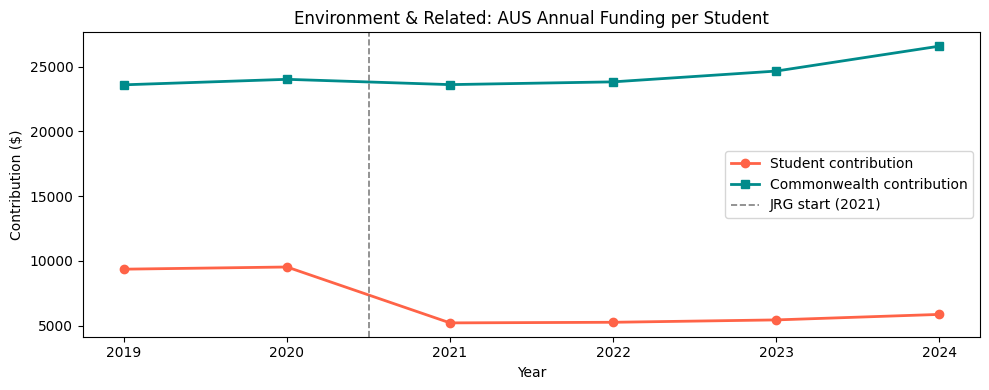


Student contribution: pre $9,443 -> post $5,446 (-42.3%)
Commonwealth:         pre $23,802 -> post $24,662 (+3.6%)


In [12]:
fund_raw  = pd.read_csv(FUND_PATH)
arch_fund = fund_raw[fund_raw['CategoryKey'] == 5].copy()
arch_fund_agg = (
    arch_fund[arch_fund['Year'] <= 2024]
    .groupby('Year')[['MaximumStudentContribution', 'CommonwealthContribution']]
    .mean()
    .round(0)
)
arch_fund_agg['total'] = arch_fund_agg['MaximumStudentContribution'] + arch_fund_agg['CommonwealthContribution']

print('=== Environment & Related: AUS Annual Funding per Student ===')
display(arch_fund_agg)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(arch_fund_agg.index, arch_fund_agg['MaximumStudentContribution'],
        'o-', color='tomato',   linewidth=2, label='Student contribution')
ax.plot(arch_fund_agg.index, arch_fund_agg['CommonwealthContribution'],
        's-', color='darkcyan', linewidth=2, label='Commonwealth contribution')
ax.axvline(2020.5, linestyle='--', color='gray', linewidth=1.2, label='JRG start (2021)')
ax.set_title('Environment & Related: AUS Annual Funding per Student')
ax.set_xlabel('Year'); ax.set_ylabel('Contribution ($)'); ax.legend()
plt.tight_layout()
plt.show()

pre_stu  = arch_fund_agg.loc[arch_fund_agg.index <= 2020, 'MaximumStudentContribution'].mean()
post_stu = arch_fund_agg.loc[arch_fund_agg.index >= 2021, 'MaximumStudentContribution'].mean()
pre_cw   = arch_fund_agg.loc[arch_fund_agg.index <= 2020, 'CommonwealthContribution'].mean()
post_cw  = arch_fund_agg.loc[arch_fund_agg.index >= 2021, 'CommonwealthContribution'].mean()
print(f'\nStudent contribution: pre ${pre_stu:,.0f} -> post ${post_stu:,.0f} ({(post_stu/pre_stu-1)*100:+.1f}%)')
print(f'Commonwealth:         pre ${pre_cw:,.0f} -> post ${post_cw:,.0f} ({(post_cw/pre_cw-1)*100:+.1f}%)')


## Results Summary

### Model specification

$$\log(E_{ct}) = \beta_0 + \beta_1 \cdot \text{Treated}_c + \beta_2 \cdot \text{DID}_{ct} + \sum_{t=2020}^{2024} \gamma_t \cdot \mathbf{1}_{[\text{year}=t]} + \varepsilon_{ct}$$

| Term | Variable | Definition |
|------|----------|------------|
| $\log(E_{ct})$ | Outcome | Log enrolments for country $c$ in year $t$ |
| $\beta_0$ | Intercept | UK baseline (2019) |
| $\beta_1 \cdot \text{Treated}_c$ | Country FE | $\text{Treated}_c = 1$ if AUS, $0$ if UK |
| $\text{Post}_t$ | --- | $= 1$ if $t \geq 2021$, else $0$ |
| $\text{DID}_{ct}$ | DiD term | $= \text{Treated}_c \times \text{Post}_t$ |
| $\beta_2$ | **JRG effect** | DiD estimate --- the coefficient of interest |
| $\gamma_t$ | Year FEs | Common time trend absorbed by year dummies |
| $\varepsilon_{ct}$ | Error | HC3 heteroscedasticity-robust standard errors |

**Implemented in statsmodels as:**
```python
formula = "log_enrollments ~ treated + did + C(year)"
model   = smf.ols(formula, data=panel).fit(cov_type="HC3")
```


| **Cell** | **Result** |
|----------|------------|
| **Main DiD** | beta = -0.0679, p = 0.556, 95% CI [-0.29, +0.16], approx. **-6.6%** relative to UK trend |
| **PanelOLS cross-check** | Estimates match exactly |
| **COVID sensitivity** | Full panel: -6.6%; Drop 2020: -1.2% (SE explodes, df=3); Drop 2020+2021: -2.6% (df=2). Sign consistently negative but highly unstable due to near-zero df |
| **Event study** | 2019 pre-trend: -10.5% (AUS already below UK before JRG). Post-2021: -7.9% (2021), -14.0% (2022), -14.7% (2023), -9.7% (2024) |
| **Placebo** | fake_post coef = +0.026, p = 0.839 -- no significant pre-trend break in AUS-only data |
| **Level spec** | beta = -3,080 students, p = 0.781, 95% CI [-24,830, +18,670] -- directionally consistent, wide CI |

**Substantive finding:** Post-JRG, AUS Environment & Related enrolments were approximately **6.6% lower**
than the UK trend would predict (p = 0.556, not significant, df = 4). Despite receiving the **largest
student fee reduction of any discipline in this analysis** (-42.3%, from $9,443 to $5,446), AUS Environment
enrolments did not respond positively relative to the UK. If anything, the relative position worsened
in 2022-2023 before partially recovering in 2024.

The event study reveals a **negative pre-existing differential**: AUS Environment was already approximately
10.5% below the UK in 2019, before JRG took effect. With only one available pre-treatment point, this is
a serious concern for the parallel trends assumption -- AUS Environment & Related may have been on a
structurally different (declining relative) trajectory before JRG. The post-2021 pattern (deepening to
-14% in 2022-23 before recovering to -10% in 2024) is therefore difficult to attribute to JRG alone.

> **Data limitation note:** UK Environment & Related data is only available from 2019 onwards (due to
> incorrect JACS taxonomy mapping in earlier years). This restricts the panel to N = 12 (df = 4),
> giving very limited statistical power. Parallel trends can only be assessed at a single pre-treatment
> point (2019). Results should be interpreted with considerable caution relative to the other disciplines.